# Dynamic Programming on Slippery FrozenLake

This notebook combines the FrozenLake MDP, Policy Evaluation, Policy Iteration, Value Iteration, and the comparison between the two planning methods into one complete example.

The purpose is not only to run the algorithms. It shows:

- which Bellman equation is used,
- what happens at every step,
- when `max` is used,
- when `argmax` is used,
- when the current policy action must be used instead,
- how state values change across iterations,
- how the values are calculated from the known MDP model,
- and why Policy Iteration and Value Iteration reach the same optimal solution.

The benchmark is the standard 4×4 slippery FrozenLake:

```text
S F F F
F H F H
F F F H
H F F G
```

The agent starts at `S`, moves over frozen tiles `F`, must avoid holes `H`, and tries to reach the goal `G`.

## 1. The MDP

The problem is a finite Markov Decision Process:

$$
\mathcal{M}
=
(\mathcal{S},\mathcal{A},P,R,\gamma).
$$

For this FrozenLake:

- $|\mathcal{S}|=16$ states,
- $|\mathcal{A}|=4$ actions,
- $P(s'|s,a)$ is known,
- $R(s,a,s')$ is known,
- $\gamma=0.99$ is used for discounting.

### State numbering

```text
 0:S   1:F   2:F   3:F
 4:F   5:H   6:F   7:H
 8:F   9:F  10:F  11:H
12:H  13:F  14:F  15:G
```

### Actions

```text
0 = Left
1 = Down
2 = Right
3 = Up
```

### Slippery transition model

If the agent selects one intended action, the environment can execute:

- the direction to one side,
- the intended direction,
- the direction to the other side,

each with probability $1/3$.

Therefore the next state is stochastic even though the action chosen by the planning algorithm is deterministic.

### Reward convention used here

This notebook uses the standard FrozenLake **transition-reward convention**:

$$
R(s,a,s')=1
$$

only when the transition enters the goal.

Every other transition gives

$$
R(s,a,s')=0.
$$

A transition into a hole terminates the episode with reward $0$.

This is different from examples where the terminal state itself is assigned a permanent value such as $+1$ or $-1$. Here, the reward is received **on the transition into the goal**, and there is no future value after termination.

## 2. Imports and the exact FrozenLake model

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np

LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3

ACTION_NAMES = {
    LEFT: "Left",
    DOWN: "Down",
    RIGHT: "Right",
    UP: "Up",
}

ACTION_SYMBOLS = {
    LEFT: "←",
    DOWN: "↓",
    RIGHT: "→",
    UP: "↑",
}

DEFAULT_MAP = [
    "SFFF",
    "FHFH",
    "FFFH",
    "HFFG",
]


class FrozenLakeMDP:
    def __init__(self, desc=None, is_slippery=True, seed=42):
        self.desc = np.asarray(
            [list(row) for row in (desc or DEFAULT_MAP)],
            dtype="<U1",
        )

        self.nrow, self.ncol = self.desc.shape
        self.nS = self.nrow * self.ncol
        self.nA = 4
        self.is_slippery = is_slippery
        self.rng = np.random.default_rng(seed)

        starts = np.argwhere(self.desc == "S")
        if len(starts) != 1:
            raise ValueError(
                "The map must contain exactly one start state."
            )

        self.start_state = self.to_state(*starts[0])

        self.goal_states = {
            self.to_state(r, c)
            for r, c in np.argwhere(self.desc == "G")
        }

        self.hole_states = {
            self.to_state(r, c)
            for r, c in np.argwhere(self.desc == "H")
        }

        self.terminal_states = (
            self.goal_states
            | self.hole_states
        )

        self.nonterminal_states = [
            state
            for state in range(self.nS)
            if state not in self.terminal_states
        ]

        self.state = self.start_state

    def to_state(self, row, col):
        return int(row * self.ncol + col)

    def to_position(self, state):
        return divmod(int(state), self.ncol)

    def tile(self, state):
        row, col = self.to_position(state)
        return self.desc[row, col]

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self.state = self.start_state
        return self.state

    def _move(self, state, action):
        row, col = self.to_position(state)

        if action == LEFT:
            col = max(col - 1, 0)

        elif action == DOWN:
            row = min(row + 1, self.nrow - 1)

        elif action == RIGHT:
            col = min(col + 1, self.ncol - 1)

        elif action == UP:
            row = max(row - 1, 0)

        else:
            raise ValueError("Invalid action.")

        next_state = self.to_state(row, col)

        reward = (
            1.0
            if next_state in self.goal_states
            else 0.0
        )

        done = (
            next_state in self.terminal_states
        )

        return next_state, reward, done

    def transition_distribution(
        self,
        state,
        action,
    ):
        if state in self.terminal_states:
            return [
                (
                    1.0,
                    state,
                    0.0,
                    True,
                )
            ]

        if self.is_slippery:
            actual_actions = [
                (
                    (action - 1) % self.nA,
                    1.0 / 3.0,
                ),
                (
                    action,
                    1.0 / 3.0,
                ),
                (
                    (action + 1) % self.nA,
                    1.0 / 3.0,
                ),
            ]

        else:
            actual_actions = [
                (
                    action,
                    1.0,
                )
            ]

        aggregated = {}

        for actual_action, probability in actual_actions:
            next_state, reward, done = self._move(
                state,
                actual_action,
            )

            key = (
                next_state,
                reward,
                done,
            )

            aggregated[key] = (
                aggregated.get(key, 0.0)
                + probability
            )

        return [
            (
                probability,
                next_state,
                reward,
                done,
            )
            for (
                next_state,
                reward,
                done,
            ), probability
            in aggregated.items()
        ]

    def step(self, action):
        dist = self.transition_distribution(
            self.state,
            action,
        )

        probabilities = np.asarray(
            [item[0] for item in dist],
            dtype=float,
        )

        index = self.rng.choice(
            len(dist),
            p=probabilities,
        )

        (
            probability,
            next_state,
            reward,
            done,
        ) = dist[index]

        previous_state = self.state
        self.state = next_state

        return (
            next_state,
            reward,
            done,
            {
                "previous_state": previous_state,
                "action": action,
                "sampled_probability": probability,
            },
        )

    def q_from_v(
        self,
        values,
        state,
        action,
        gamma,
    ):
        return sum(
            probability
            * (
                reward
                + gamma
                * (
                    0.0
                    if done
                    else values[next_state]
                )
            )
            for (
                probability,
                next_state,
                reward,
                done,
            )
            in self.transition_distribution(
                state,
                action,
            )
        )

    def render_map(self):
        return "\n".join(
            " ".join(row)
            for row in self.desc
        )

    def render_state_numbers(self):
        rows = []

        for row in range(self.nrow):
            formatted = []

            for col in range(self.ncol):
                state = self.to_state(
                    row,
                    col,
                )

                formatted.append(
                    f"{state:2d}:{self.desc[row, col]}"
                )

            rows.append(
                "  ".join(formatted)
            )

        return "\n".join(rows)

    def render_values(
        self,
        values,
        decimals=4,
    ):
        rows = []

        for row in range(self.nrow):
            formatted = []

            for col in range(self.ncol):
                state = self.to_state(
                    row,
                    col,
                )

                tile = self.tile(state)

                if tile == "H":
                    formatted.append(
                        "   H   "
                    )

                elif tile == "G":
                    formatted.append(
                        "   G   "
                    )

                else:
                    formatted.append(
                        f"{values[state]:7.{decimals}f}"
                    )

            rows.append(
                " ".join(formatted)
            )

        return "\n".join(rows)

    def render_policy(self, actions):
        rows = []

        for row in range(self.nrow):
            formatted = []

            for col in range(self.ncol):
                state = self.to_state(
                    row,
                    col,
                )

                tile = self.tile(state)

                if tile in ("H", "G"):
                    formatted.append(tile)

                elif tile == "S":
                    formatted.append(
                        "S"
                        + ACTION_SYMBOLS[
                            int(actions[state])
                        ]
                    )

                else:
                    formatted.append(
                        ACTION_SYMBOLS[
                            int(actions[state])
                        ]
                    )

            rows.append(
                "  ".join(formatted)
            )

        return "\n".join(rows)

## 3. Dynamic Programming helper functions

In [ ]:
def uniform_random_policy(env):
    return np.full(
        (
            env.nS,
            env.nA,
        ),
        1.0 / env.nA,
        dtype=float,
    )


def deterministic_policy_matrix(
    env,
    actions,
):
    policy = np.zeros(
        (
            env.nS,
            env.nA,
        ),
        dtype=float,
    )

    for state in range(env.nS):
        if state in env.terminal_states:
            policy[state, :] = (
                1.0 / env.nA
            )

        else:
            policy[
                state,
                int(actions[state]),
            ] = 1.0

    return policy


def policy_evaluation(
    env,
    policy,
    gamma=0.99,
    theta=1e-10,
    max_sweeps=100000,
):
    values = np.zeros(
        env.nS,
        dtype=float,
    )

    deltas = []
    q_backups = 0

    for sweep in range(
        1,
        max_sweeps + 1,
    ):
        new_values = values.copy()
        delta = 0.0

        for state in env.nonterminal_states:
            value = 0.0

            for action in range(env.nA):
                action_probability = (
                    policy[
                        state,
                        action,
                    ]
                )

                if action_probability == 0.0:
                    continue

                value += (
                    action_probability
                    * env.q_from_v(
                        values,
                        state,
                        action,
                        gamma,
                    )
                )

                q_backups += 1

            new_values[state] = value

            delta = max(
                delta,
                abs(
                    new_values[state]
                    - values[state]
                ),
            )

        values = new_values
        deltas.append(delta)

        if delta < theta:
            return (
                values,
                sweep,
                deltas,
                q_backups,
            )

    raise RuntimeError(
        "Policy evaluation did not converge."
    )


def policy_evaluation_trace(
    env,
    policy,
    sweeps_to_record=5,
    gamma=0.99,
):
    values = np.zeros(
        env.nS,
        dtype=float,
    )

    history = [
        values.copy()
    ]

    for _ in range(
        sweeps_to_record
    ):
        new_values = values.copy()

        for state in env.nonterminal_states:
            new_values[state] = sum(
                policy[state, action]
                * env.q_from_v(
                    values,
                    state,
                    action,
                    gamma,
                )
                for action
                in range(env.nA)
                if policy[state, action] > 0.0
            )

        values = new_values
        history.append(
            values.copy()
        )

    return history


def greedy_policy_from_v(
    env,
    values,
    gamma=0.99,
):
    actions = np.zeros(
        env.nS,
        dtype=int,
    )

    q_table = np.zeros(
        (
            env.nS,
            env.nA,
        ),
        dtype=float,
    )

    q_backups = 0

    for state in env.nonterminal_states:
        for action in range(env.nA):
            q_table[
                state,
                action,
            ] = env.q_from_v(
                values,
                state,
                action,
                gamma,
            )

            q_backups += 1

        actions[state] = int(
            np.argmax(
                q_table[state]
            )
        )

    return (
        actions,
        q_table,
        q_backups,
    )


def policy_iteration_trace(
    env,
    gamma=0.99,
    theta=1e-10,
    max_iterations=1000,
):
    actions = np.zeros(
        env.nS,
        dtype=int,
    )

    history = []
    total_eval_backups = 0
    total_improvement_backups = 0

    for iteration in range(
        1,
        max_iterations + 1,
    ):
        old_actions = actions.copy()

        policy = (
            deterministic_policy_matrix(
                env,
                old_actions,
            )
        )

        (
            values,
            sweeps,
            deltas,
            eval_backups,
        ) = policy_evaluation(
            env,
            policy,
            gamma=gamma,
            theta=theta,
        )

        (
            new_actions,
            q_table,
            improve_backups,
        ) = greedy_policy_from_v(
            env,
            values,
            gamma=gamma,
        )

        changes = sum(
            int(
                new_actions[state]
                != old_actions[state]
            )
            for state
            in env.nonterminal_states
        )

        total_eval_backups += (
            eval_backups
        )

        total_improvement_backups += (
            improve_backups
        )

        history.append(
            {
                "iteration": iteration,
                "old_actions": old_actions.copy(),
                "values": values.copy(),
                "new_actions": new_actions.copy(),
                "q_table": q_table.copy(),
                "evaluation_sweeps": sweeps,
                "evaluation_deltas": deltas.copy(),
                "policy_changes": changes,
                "start_value": float(
                    values[
                        env.start_state
                    ]
                ),
            }
        )

        actions = new_actions

        if changes == 0:
            return {
                "values": values,
                "actions": actions,
                "q_table": q_table,
                "history": history,
                "total_evaluation_q_backups": total_eval_backups,
                "total_improvement_q_backups": total_improvement_backups,
                "total_q_backups": (
                    total_eval_backups
                    + total_improvement_backups
                ),
            }

    raise RuntimeError(
        "Policy iteration did not converge."
    )


def value_iteration_trace(
    env,
    gamma=0.99,
    theta=1e-10,
    max_sweeps=100000,
):
    values = np.zeros(
        env.nS,
        dtype=float,
    )

    history = [
        values.copy()
    ]

    deltas = []
    q_backups = 0

    for sweep in range(
        1,
        max_sweeps + 1,
    ):
        new_values = values.copy()
        delta = 0.0

        for state in env.nonterminal_states:
            q_values = []

            for action in range(env.nA):
                q_values.append(
                    env.q_from_v(
                        values,
                        state,
                        action,
                        gamma,
                    )
                )

                q_backups += 1

            new_values[state] = max(
                q_values
            )

            delta = max(
                delta,
                abs(
                    new_values[state]
                    - values[state]
                ),
            )

        values = new_values
        history.append(
            values.copy()
        )
        deltas.append(delta)

        if delta < theta:
            (
                actions,
                q_table,
                extraction_backups,
            ) = greedy_policy_from_v(
                env,
                values,
                gamma=gamma,
            )

            return {
                "values": values,
                "actions": actions,
                "q_table": q_table,
                "sweeps": sweep,
                "deltas": deltas,
                "history": history,
                "iteration_q_backups": q_backups,
                "extraction_q_backups": extraction_backups,
                "total_q_backups": (
                    q_backups
                    + extraction_backups
                ),
            }

    raise RuntimeError(
        "Value iteration did not converge."
    )


def sample_action_from_policy(
    policy,
    state,
    rng,
):
    return int(
        rng.choice(
            policy.shape[1],
            p=np.asarray(
                policy[state],
                dtype=float,
            ),
        )
    )


def evaluate_policy_by_simulation(
    env,
    policy,
    episodes=3000,
    max_steps=100,
    seed=2026,
):
    rng = np.random.default_rng(
        seed
    )

    successes = 0
    returns = []
    lengths = []

    for _ in range(episodes):
        env.reset(
            seed=int(
                rng.integers(
                    0,
                    2**31 - 1,
                )
            )
        )

        episode_return = 0.0

        for step in range(
            1,
            max_steps + 1,
        ):
            action = sample_action_from_policy(
                policy,
                env.state,
                rng,
            )

            (
                _,
                reward,
                done,
                _,
            ) = env.step(
                action
            )

            episode_return += reward

            if done:
                successes += int(
                    reward > 0.0
                )

                lengths.append(
                    step
                )

                break

        else:
            lengths.append(
                max_steps
            )

        returns.append(
            episode_return
        )

    return {
        "episodes": episodes,
        "success_rate": successes / episodes,
        "average_return": float(
            np.mean(returns)
        ),
        "average_episode_length": float(
            np.mean(lengths)
        ),
    }


def show_action_backup(
    env,
    values,
    state,
    action,
    gamma=0.99,
):
    print(
        f"State {state}, "
        f"action {ACTION_NAMES[action]}"
    )

    print(
        "P        next  tile  reward  "
        "done   V_old(next)  contribution"
    )

    total = 0.0

    for (
        probability,
        next_state,
        reward,
        done,
    ) in env.transition_distribution(
        state,
        action,
    ):
        future_value = (
            0.0
            if done
            else values[next_state]
        )

        contribution = (
            probability
            * (
                reward
                + gamma
                * future_value
            )
        )

        total += contribution

        print(
            f"{probability:<8.4f}"
            f"{next_state:<6}"
            f"{env.tile(next_state):<6}"
            f"{reward:<8.4f}"
            f"{str(done):<7}"
            f"{future_value:<13.8f}"
            f"{contribution:.8f}"
        )

    print(
        "\nQ(s,a) =",
        total,
    )

    return total


def print_all_action_values(
    env,
    values,
    state,
    gamma=0.99,
):
    q_values = np.array(
        [
            env.q_from_v(
                values,
                state,
                action,
                gamma,
            )
            for action
            in range(env.nA)
        ]
    )

    for action in range(env.nA):
        print(
            f"{ACTION_NAMES[action]:>5}: "
            f"{q_values[action]:.8f}"
        )

    print(
        "\nmax value:",
        np.max(q_values),
    )

    print(
        "argmax action:",
        ACTION_NAMES[
            int(
                np.argmax(
                    q_values
                )
            )
        ],
    )

    return q_values

## 4. Create and verify the benchmark

In [ ]:
env = FrozenLakeMDP(
    is_slippery=True,
    seed=42,
)

gamma = 0.99
theta = 1e-10

print("FrozenLake map:")
print(env.render_map())

print("\nState numbering:")
print(env.render_state_numbers())

print("\nStart state:", env.start_state)
print("Hole states:", sorted(env.hole_states))
print("Goal states:", sorted(env.goal_states))

goal_outcomes = env.transition_distribution(
    14,
    RIGHT,
)

assert any(
    next_state == 15
    and reward == 1.0
    and done
    for (
        _,
        next_state,
        reward,
        done,
    )
    in goal_outcomes
)

hole_outcomes = env.transition_distribution(
    10,
    DOWN,
)

assert any(
    next_state == 11
    and reward == 0.0
    and done
    for (
        _,
        next_state,
        reward,
        done,
    )
    in hole_outcomes
)

for state in range(env.nS):
    for action in range(env.nA):
        probability_sum = sum(
            probability
            for (
                probability,
                _,
                _,
                _,
            )
            in env.transition_distribution(
                state,
                action,
            )
        )

        assert np.isclose(
            probability_sum,
            1.0,
        )

print(
    "\nAll transition, reward, "
    "terminal, and probability checks passed."
)

FrozenLake map:
S F F F
F H F H
F F F H
H F F G

State numbering:
 0:S   1:F   2:F   3:F
 4:F   5:H   6:F   7:H
 8:F   9:F  10:F  11:H
12:H  13:F  14:F  15:G

Start state: 0
Hole states: [5, 7, 11, 12]
Goal states: [15]

All transition, reward, terminal, and probability checks passed.


## 5. One expected action value comes directly from the model

For any state $s$ and action $a$, define the one-step expected action value from the current value estimate $V_k$ as

$$
Q_k(s,a)
=
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V_k(s')
\right].
$$

If $s'$ is terminal, there is no continuation after that transition. The implementation therefore uses continuation value $0$ after termination.

This quantity is the basic building block used by all the Dynamic Programming methods below.

The next cell asks the MDP model for the possible outcomes of taking `Right` from state $14$. No transition probability or reward is entered manually.

In [ ]:
state = 14
action = RIGHT
zero_values = np.zeros(env.nS)

show_action_backup(
    env,
    zero_values,
    state,
    action,
    gamma,
)

State 14, action Right
P        next  tile  reward  done   V_old(next)  contribution
0.3333  14    F     0.0000  False  0.00000000   0.00000000
0.3333  15    G     1.0000  True   0.00000000   0.33333333
0.3333  10    F     0.0000  False  0.00000000   0.00000000

Q(s,a) = 0.3333333333333333


np.float64(0.3333333333333333)

With all initial values equal to $0$, only a transition that immediately enters the goal contributes positive value.

The model output above therefore shows exactly how $Q_0(14,\text{Right})$ is calculated.

# Part I — Policy Evaluation

## 6. What Policy Evaluation does

Policy Evaluation answers:

> If the current policy continues to be followed, what is the value of each state?

For a stochastic policy $\pi(a|s)$, the Bellman expectation update is

$$
V_{k+1}^{\pi}(s)
=
\sum_a
\pi(a|s)
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V_k^{\pi}(s')
\right].
$$

The important point is:

$$
\boxed{
\text{Policy Evaluation does not take a maximum over actions.}
}
$$

It uses the action probabilities specified by the current policy.

For a deterministic policy, the policy selects only one action $\pi(s)$. Then the equation becomes

$$
V_{k+1}^{\pi}(s)
=
\sum_{s'}
P(s'|s,\pi(s))
\left[
R(s,\pi(s),s')
+
\gamma V_k^{\pi}(s')
\right].
$$

So if the current policy says `Left`, Policy Evaluation evaluates `Left`. It does not replace it with a better action.

## 7. Evaluate a uniform random policy

In [ ]:
random_policy = uniform_random_policy(
    env
)

print(
    "Action probabilities at state 0:"
)

for action in range(env.nA):
    print(
        f"{ACTION_NAMES[action]:>5}: "
        f"{random_policy[0, action]:.2f}"
    )

Action probabilities at state 0:
 Left: 0.25
 Down: 0.25
Right: 0.25
   Up: 0.25


For this policy,

$$
\pi(a|s)=0.25
$$

for every action at every non-terminal state.

A Policy Evaluation sweep updates all non-terminal states using the same fixed policy.

In [ ]:
random_history = policy_evaluation_trace(
    env,
    random_policy,
    sweeps_to_record=5,
    gamma=gamma,
)

for sweep in range(
    len(random_history)
):
    print(
        f"Policy Evaluation sweep {sweep}"
    )

    print(
        env.render_values(
            random_history[sweep]
        )
    )

    print()

Policy Evaluation sweep 0
 0.0000  0.0000  0.0000  0.0000
 0.0000    H     0.0000    H   
 0.0000  0.0000  0.0000    H   
   H     0.0000  0.0000    G   

Policy Evaluation sweep 1
 0.0000  0.0000  0.0000  0.0000
 0.0000    H     0.0000    H   
 0.0000  0.0000  0.0000    H   
   H     0.0000  0.2500    G   

Policy Evaluation sweep 2
 0.0000  0.0000  0.0000  0.0000
 0.0000    H     0.0000    H   
 0.0000  0.0000  0.0619    H   
   H     0.0619  0.3119    G   

Policy Evaluation sweep 3
 0.0000  0.0000  0.0000  0.0000
 0.0000    H     0.0153    H   
 0.0000  0.0306  0.0772    H   
   H     0.0925  0.3578    G   

Policy Evaluation sweep 4
 0.0000  0.0000  0.0038  0.0000
 0.0000    H     0.0191    H   
 0.0076  0.0420  0.0999    H   
   H     0.1190  0.3806    G   

Policy Evaluation sweep 5
 0.0000  0.0009  0.0057  0.0009
 0.0019    H     0.0257    H   
 0.0123  0.0561  0.1093    H   
   H     0.1340  0.3984    G   



The values change because reward information propagates through the known transition model. The policy itself does not change during these sweeps.

## 8. Continue Policy Evaluation until convergence

In [ ]:
(
    random_values,
    random_sweeps,
    random_deltas,
    random_q_backups,
) = policy_evaluation(
    env,
    random_policy,
    gamma=gamma,
    theta=theta,
)

print(
    "Policy-evaluation sweeps:",
    random_sweeps,
)

print(
    "Start-state value:",
    random_values[
        env.start_state
    ],
)

print(
    "\nConverged values:"
)

print(
    env.render_values(
        random_values
    )
)

Policy-evaluation sweeps: 93
Start-state value: 0.012356136912377837

Converged values:
 0.0124  0.0104  0.0193  0.0095
 0.0148    H     0.0389    H   
 0.0326  0.0843  0.1378    H   
   H     0.1703  0.4336    G   


The stopping condition is

$$
\delta_k
=
\max_s
\left|
V_{k+1}^{\pi}(s)
-
V_k^{\pi}(s)
\right|
<
\theta.
$$

Here $\theta=10^{-10}$.

This means the **values** have stabilized for the fixed policy. It does not mean the policy itself has been improved.

## 9. Verify the Bellman expectation equation after convergence

In [ ]:
state = 0
bellman_rhs = 0.0

for action in range(env.nA):
    q_value = env.q_from_v(
        random_values,
        state,
        action,
        gamma,
    )

    weighted_contribution = (
        random_policy[
            state,
            action,
        ]
        * q_value
    )

    bellman_rhs += (
        weighted_contribution
    )

    print(
        f"{ACTION_NAMES[action]:>5}: "
        f"pi={random_policy[state, action]:.2f}, "
        f"Q={q_value:.10f}, "
        f"pi*Q={weighted_contribution:.10f}"
    )

print(
    "\nBellman RHS:",
    bellman_rhs,
)

print(
    "Stored V^pi(0):",
    random_values[state],
)

print(
    "Absolute difference:",
    abs(
        bellman_rhs
        - random_values[state]
    ),
)

 Left: pi=0.25, Q=0.0130347773, pi*Q=0.0032586943
 Down: pi=0.25, Q=0.0123973241, pi*Q=0.0030993310
Right: pi=0.25, Q=0.0123973241, pi*Q=0.0030993310
   Up: pi=0.25, Q=0.0115951224, pi*Q=0.0028987806

Bellman RHS: 0.012356136988536824
Stored V^pi(0): 0.012356136912377837
Absolute difference: 7.615898710289226e-11


After convergence, the independently calculated Bellman right-hand side matches the stored $V^{\pi}(0)$ within the numerical tolerance.

# Part II — Policy Iteration

## 10. Policy Iteration in simple steps

Policy Iteration repeatedly alternates between two operations:

```text
Choose an initial policy
        ↓
Policy Evaluation
        ↓
Find V^π for the current policy
        ↓
Policy Improvement
        ↓
Choose the greedy action at each state
        ↓
Did the policy change?
      ↙        ↘
    Yes         No
     ↓           ↓
 Evaluate       Stop
 again
```

### Step A — Policy Evaluation

Keep the current policy fixed and calculate $V^{\pi}$.

For a deterministic policy:

$$
V_{k+1}^{\pi}(s)
=
\sum_{s'}
P(s'|s,\pi(s))
\left[
R(s,\pi(s),s')
+
\gamma V_k^{\pi}(s')
\right].
$$

There is **no** $\max$ in this step.

### Step B — Policy Improvement

After $V^{\pi}$ has converged, calculate all possible action values:

$$
Q^{\pi}(s,a)
=
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^{\pi}(s')
\right].
$$

Then choose the action with the largest value:

$$
\pi_{\text{new}}(s)
=
\arg\max_a
Q^{\pi}(s,a).
$$

Equivalently,

$$
\boxed{
\pi_{\text{new}}(s)
=
\arg\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^{\pi}(s')
\right]
}
$$

The $\sum_{s'}$ averages over possible stochastic next states. The $\arg\max_a$ selects the action.

Policy Iteration stops when

$$
\pi_{\text{new}}(s)
=
\pi(s)
$$

for every non-terminal state.

## 11. Start Policy Iteration with an all-Left policy

In [ ]:
initial_actions = np.zeros(
    env.nS,
    dtype=int,
)

print(
    env.render_policy(
        initial_actions
    )
)

S←  ←  ←  ←
←  H  ←  H
←  ←  ←  H
H  ←  ←  G


The initial policy says `Left` at every non-terminal state.

During the first Policy Evaluation, the algorithm must follow this policy. It is not allowed to select the best action yet.

## 12. First Policy Evaluation

In [ ]:
initial_policy_matrix = (
    deterministic_policy_matrix(
        env,
        initial_actions,
    )
)

(
    initial_policy_values,
    initial_policy_sweeps,
    initial_policy_deltas,
    _,
) = policy_evaluation(
    env,
    initial_policy_matrix,
    gamma=gamma,
    theta=theta,
)

print(
    "Evaluation sweeps:",
    initial_policy_sweeps,
)

print(
    "\nValues of the all-Left policy:"
)

print(
    env.render_values(
        initial_policy_values
    )
)

Evaluation sweeps: 1

Values of the all-Left policy:
 0.0000  0.0000  0.0000  0.0000
 0.0000    H     0.0000    H   
 0.0000  0.0000  0.0000    H   
   H     0.0000  0.0000    G   


For this particular initial policy, the positive goal reward is unreachable while repeatedly intending `Left`, so the evaluated values are $0$.

The next cell shows state $14$ specifically. Policy Evaluation uses only the action `Left`, because that is what the current policy specifies.

In [ ]:
show_action_backup(
    env,
    initial_policy_values,
    state=14,
    action=LEFT,
    gamma=gamma,
)

State 14, action Left
P        next  tile  reward  done   V_old(next)  contribution
0.3333  10    F     0.0000  False  0.00000000   0.00000000
0.3333  13    F     0.0000  False  0.00000000   0.00000000
0.3333  14    F     0.0000  False  0.00000000   0.00000000

Q(s,a) = 0.0


np.float64(0.0)

There is still no $\max$ here. The current policy says `Left`, so the Bellman expectation backup evaluates `Left`.

## 13. First Policy Improvement at state 14

Now Policy Evaluation is complete. Policy Improvement is allowed to compare all four actions.

The code below calculates $Q^{\pi}(14,a)$ directly from the known model for every action.

In [ ]:
q_values_state_14 = (
    print_all_action_values(
        env,
        initial_policy_values,
        state=14,
        gamma=gamma,
    )
)

 Left: 0.00000000
 Down: 0.33333333
Right: 0.33333333
   Up: 0.33333333

max value: 0.3333333333333333
argmax action: Down


Policy Improvement uses

$$
\arg\max_a Q^{\pi}(14,a)
$$

to choose an action.

If several actions are exactly tied, `numpy.argmax` returns the first maximum according to the action index order. A tie can therefore affect the intermediate policy path without changing the optimal value solution.

## 14. Run the complete Policy Iteration and show every outer step

In [ ]:
start_time = time.perf_counter()

pi_result = policy_iteration_trace(
    env,
    gamma=gamma,
    theta=theta,
)

pi_time = (
    time.perf_counter()
    - start_time
)

for record in pi_result["history"]:
    print(
        "=" * 70
    )

    print(
        "Policy Iteration:",
        record["iteration"],
    )

    print(
        "Policy Evaluation sweeps:",
        record[
            "evaluation_sweeps"
        ],
    )

    print(
        "Policy changes:",
        record[
            "policy_changes"
        ],
    )

    print(
        "Start-state value:",
        f"{record['start_value']:.10f}",
    )

    print(
        "\nPolicy being evaluated:"
    )

    print(
        env.render_policy(
            record["old_actions"]
        )
    )

    print(
        "\nValues after evaluating "
        "that policy:"
    )

    print(
        env.render_values(
            record["values"]
        )
    )

    print(
        "\nGreedy improved policy:"
    )

    print(
        env.render_policy(
            record["new_actions"]
        )
    )

    print()

Policy Iteration: 1
Policy Evaluation sweeps: 1
Policy changes: 1
Start-state value: 0.0000000000

Policy being evaluated:
S←  ←  ←  ←
←  H  ←  H
←  ←  ←  H
H  ←  ←  G

Values after evaluating that policy:
 0.0000  0.0000  0.0000  0.0000
 0.0000    H     0.0000    H   
 0.0000  0.0000  0.0000    H   
   H     0.0000  0.0000    G   

Greedy improved policy:
S←  ←  ←  ←
←  H  ←  H
←  ←  ←  H
H  ←  ↓  G

Policy Iteration: 2
Policy Evaluation sweeps: 42
Policy changes: 6
Start-state value: 0.0000000000

Policy being evaluated:
S←  ←  ←  ←
←  H  ←  H
←  ←  ←  H
H  ←  ↓  G

Values after evaluating that policy:
 0.0000  0.0000  0.0366  0.0180
 0.0000    H     0.0744    H   
 0.0000  0.0000  0.1887    H   
   H     0.0000  0.4975    G   

Greedy improved policy:
S←  ↓  →  ↑
←  H  ←  H
←  ↓  ←  H
H  ↓  →  G

Policy Iteration: 3
Policy Evaluation sweeps: 213
Policy changes: 4
Start-state value: 0.0000000000

Policy being evaluated:
S←  ↓  →  ↑
←  H  ←  H
←  ↓  ←  H
H  ↓  →  G

Values after evalu

This output shows the two nested processes clearly:

1. the inner Policy Evaluation sweeps continue until $V^{\pi}$ converges for the current policy,
2. the outer Policy Iteration step then changes the policy using $\arg\max_a$,
3. the new policy is evaluated again,
4. the procedure stops when the number of changed actions becomes $0$.

## 15. Final Policy Iteration solution

In [ ]:
print(
    "Outer policy iterations:",
    len(
        pi_result["history"]
    ),
)

print(
    "Final start-state value:",
    pi_result["values"][
        env.start_state
    ],
)

print(
    "\nFinal values:"
)

print(
    env.render_values(
        pi_result["values"]
    )
)

print(
    "\nFinal policy:"
)

print(
    env.render_policy(
        pi_result["actions"]
    )
)

Outer policy iterations: 7
Final start-state value: 0.5420259303701579

Final values:
 0.5420  0.4988  0.4707  0.4569
 0.5585    H     0.3583    H   
 0.5918  0.6431  0.6152    H   
   H     0.7417  0.8628    G   

Final policy:
S←  ↑  ↑  ↑
←  H  ←  H
↑  ↓  ←  H
H  →  ↓  G


# Part III — Value Iteration

## 16. Value Iteration in simple steps

Value Iteration does not completely evaluate one fixed policy before improving it.

Instead, every sweep directly applies the Bellman optimality update:

$$
\boxed{
V_{k+1}(s)
=
\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V_k(s')
\right]
}
$$

For each state $s$:

1. use the current values $V_k$,
2. calculate $Q_k(s,a)$ for every action $a$,
3. take the maximum action value,
4. store that maximum as $V_{k+1}(s)$,
5. repeat for every non-terminal state,
6. continue sweeping until the values converge.

The action-value calculation is

$$
Q_k(s,a)
=
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V_k(s')
\right].
$$

Then

$$
V_{k+1}(s)
=
\max_a Q_k(s,a).
$$

The $\max$ is required in Value Iteration because it is what moves the value function toward the optimal value function $V^*$.

Notice the difference:

- $\max_a$ returns the best **value**,
- $\arg\max_a$ returns the **action** that produced that best value.

## 17. Initialize the state values

In [ ]:
initial_values = np.zeros(
    env.nS,
    dtype=float,
)

print(
    "V0:"
)

print(
    env.render_values(
        initial_values
    )
)

V0:
 0.0000  0.0000  0.0000  0.0000
 0.0000    H     0.0000    H   
 0.0000  0.0000  0.0000    H   
   H     0.0000  0.0000    G   


Initially,

$$
V_0(s)=0
$$

for every state.

The first Value Iteration sweep calculates every possible action from these values.

## 18. First Value Iteration backup at state 14

In [ ]:
print(
    "Action values at state 14 "
    "using V0:\n"
)

first_state_14_q = (
    print_all_action_values(
        env,
        initial_values,
        state=14,
        gamma=gamma,
    )
)

Action values at state 14 using V0:

 Left: 0.00000000
 Down: 0.33333333
Right: 0.33333333
   Up: 0.33333333

max value: 0.3333333333333333
argmax action: Down


The new value is

$$
V_1(14)
=
\max_a Q_0(14,a).
$$

The code above calculates the action values directly from $P(s'|s,a)$ and $R(s,a,s')$ in the model.

To see one action in full detail:

In [ ]:
show_action_backup(
    env,
    initial_values,
    state=14,
    action=RIGHT,
    gamma=gamma,
)

State 14, action Right
P        next  tile  reward  done   V_old(next)  contribution
0.3333  14    F     0.0000  False  0.00000000   0.00000000
0.3333  15    G     1.0000  True   0.00000000   0.33333333
0.3333  10    F     0.0000  False  0.00000000   0.00000000

Q(s,a) = 0.3333333333333333


np.float64(0.3333333333333333)

The transition into the goal contributes immediate reward $1$. The terminal transition has no discounted continuation value.

## 19. Show the first Value Iteration sweeps

In [ ]:
vi_preview = value_iteration_trace(
    env,
    gamma=gamma,
    theta=theta,
)

for sweep in range(0, 6):
    print(
        f"Value Iteration sweep {sweep}"
    )

    print(
        env.render_values(
            vi_preview[
                "history"
            ][sweep]
        )
    )

    print()

Value Iteration sweep 0
 0.0000  0.0000  0.0000  0.0000
 0.0000    H     0.0000    H   
 0.0000  0.0000  0.0000    H   
   H     0.0000  0.0000    G   

Value Iteration sweep 1
 0.0000  0.0000  0.0000  0.0000
 0.0000    H     0.0000    H   
 0.0000  0.0000  0.0000    H   
   H     0.0000  0.3333    G   

Value Iteration sweep 2
 0.0000  0.0000  0.0000  0.0000
 0.0000    H     0.0000    H   
 0.0000  0.0000  0.1100    H   
   H     0.1100  0.4433    G   

Value Iteration sweep 3
 0.0000  0.0000  0.0000  0.0000
 0.0000    H     0.0363    H   
 0.0000  0.0726  0.1463    H   
   H     0.1826  0.5159    G   

Value Iteration sweep 4
 0.0000  0.0000  0.0120  0.0000
 0.0000    H     0.0483    H   
 0.0240  0.1085  0.2062    H   
   H     0.2545  0.5638    G   

Value Iteration sweep 5
 0.0000  0.0040  0.0199  0.0040
 0.0079    H     0.0720    H   
 0.0437  0.1599  0.2378    H   
   H     0.3059  0.6034    G   



These are synchronous updates. Every value in sweep $k+1$ is calculated from the completed value table $V_k$.

For example:

$$
V_1(14)
=
\max_a Q_0(14,a),
$$

then

$$
V_2(14)
=
\max_a Q_1(14,a),
$$

and so on.

The next cell prints the action values at state $14$ using the value tables from the first few sweeps so the numerical progression is explicit.

In [ ]:
for k in range(3):
    values_k = (
        vi_preview[
            "history"
        ][k]
    )

    print(
        "=" * 55
    )

    print(
        f"Using V{k} to compute "
        f"V{k+1}(14)"
    )

    q_values = []

    for action in range(env.nA):
        q_value = env.q_from_v(
            values_k,
            14,
            action,
            gamma,
        )

        q_values.append(
            q_value
        )

        print(
            f"{ACTION_NAMES[action]:>5}: "
            f"{q_value:.10f}"
        )

    print(
        f"V{k+1}(14) = max = "
        f"{max(q_values):.10f}"
    )

    print()

Using V0 to compute V1(14)
 Left: 0.0000000000
 Down: 0.3333333333
Right: 0.3333333333
   Up: 0.3333333333
V1(14) = max = 0.3333333333

Using V1 to compute V2(14)
 Left: 0.1100000000
 Down: 0.4433333333
Right: 0.4433333333
   Up: 0.3333333333
V2(14) = max = 0.4433333333

Using V2 to compute V3(14)
 Left: 0.2189000000
 Down: 0.5159333333
Right: 0.5159333333
   Up: 0.4059333333
V3(14) = max = 0.5159333333



This is the defining operation of Value Iteration:

$$
\boxed{
\text{calculate all action values}
\rightarrow
\text{take }\max
\rightarrow
\text{store the new state value}
}
$$

No fixed policy is being evaluated in this loop.

## 20. Run Value Iteration until convergence

In [ ]:
start_time = time.perf_counter()

vi_result = value_iteration_trace(
    env,
    gamma=gamma,
    theta=theta,
)

vi_time = (
    time.perf_counter()
    - start_time
)

print(
    "Value-iteration sweeps:",
    vi_result["sweeps"],
)

print(
    "Final Bellman residual:",
    vi_result["deltas"][-1],
)

print(
    "Final start-state value:",
    vi_result["values"][
        env.start_state
    ],
)

print(
    "\nOptimal values:"
)

print(
    env.render_values(
        vi_result["values"]
    )
)

Value-iteration sweeps: 571
Final Bellman residual: 9.788014843081783e-11
Final start-state value: 0.5420259303624805

Optimal values:
 0.5420  0.4988  0.4707  0.4569
 0.5585    H     0.3583    H   
 0.5918  0.6431  0.6152    H   
   H     0.7417  0.8628    G   


Value Iteration stops when

$$
\delta_k
=
\max_s
\left|
V_{k+1}(s)-V_k(s)
\right|
<
\theta.
$$

After convergence, the result approximates the optimal state-value function $V^*$.

## 21. Inspect the final Value Iteration decision at state 14

In [ ]:
print(
    "Final action values at state 14:"
)

final_state_14_q = (
    print_all_action_values(
        env,
        vi_result["values"],
        state=14,
        gamma=gamma,
    )
)

Final action values at state 14:
 Left: 0.73252259
 Down: 0.86283743
Right: 0.82108818
   Up: 0.78111957

max value: 0.8628374298052919
argmax action: Down


The converged optimal value satisfies

$$
V^*(14)
=
\max_a Q^*(14,a).
$$

The maximum gives the numerical value $V^*(14)$.

To obtain the action itself, use $\arg\max$.

## 22. Extract the greedy optimal policy from the converged values

After Value Iteration has converged, the optimal greedy policy is extracted with

$$
\boxed{
\pi^*(s)
=
\arg\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^*(s')
\right]
}
$$

The $\sum_{s'}$ calculates the expected result of one action across all possible next states.

The $\arg\max_a$ selects which action gives the largest expected value.

This is why the expression is **not** $\arg\max_{s'}$. The environment determines the possible next states probabilistically; the agent chooses the action.

In [ ]:
print(
    env.render_policy(
        vi_result["actions"]
    )
)

S←  ↑  ↑  ↑
←  H  ←  H
↑  ↓  ←  H
H  →  ↓  G


The important relationship is:

$$
V^*(s)
=
\max_a Q^*(s,a)
$$

but

$$
\pi^*(s)
=
\arg\max_a Q^*(s,a).
$$

So `max` returns the optimal value, while `argmax` returns the greedy action.

## 23. Value Iteration convergence plot

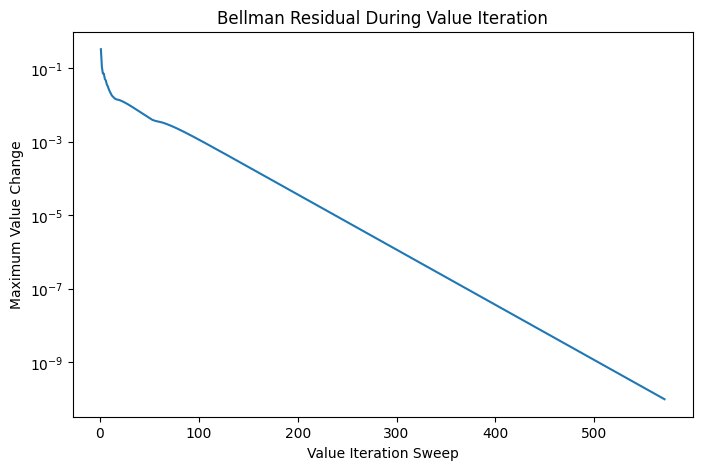

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(
        1,
        len(
            vi_result[
                "deltas"
            ]
        )
        + 1,
    ),
    vi_result[
        "deltas"
    ],
)

plt.yscale("log")
plt.xlabel(
    "Value Iteration Sweep"
)
plt.ylabel(
    "Maximum Value Change"
)
plt.title(
    "Bellman Residual During Value Iteration"
)
plt.show()

# Part IV — Policy Iteration versus Value Iteration

## 24. The central difference

### Policy Iteration

Policy Iteration explicitly maintains a policy.

```text
Current policy
      ↓
Policy Evaluation
      ↓
Use only the action prescribed by the policy
      ↓
V^π converges
      ↓
Policy Improvement
      ↓
Use argmax over all actions
      ↓
New policy
      ↓
Repeat until policy is stable
```

Its evaluation equation is

$$
V_{k+1}^{\pi}(s)
=
\sum_{s'}
P(s'|s,\pi(s))
\left[
R(s,\pi(s),s')
+
\gamma V_k^{\pi}(s')
\right].
$$

Its improvement equation is

$$
\pi_{\text{new}}(s)
=
\arg\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^{\pi}(s')
\right].
$$

### Value Iteration

Value Iteration does not completely evaluate a fixed policy.

```text
Current values
      ↓
For every state, calculate every action
      ↓
Take max action value
      ↓
Update state value
      ↓
Repeat until values converge
      ↓
Use argmax to extract the final policy
```

Its update equation is

$$
V_{k+1}(s)
=
\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V_k(s')
\right].
$$

After convergence,

$$
\pi^*(s)
=
\arg\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^*(s')
\right].
$$

## 25. Compare the final value functions

In [ ]:
value_difference = np.max(
    np.abs(
        pi_result["values"]
        - vi_result["values"]
    )
)

print(
    "Maximum absolute value difference:",
    value_difference,
)

print(
    "\nPolicy Iteration values:"
)

print(
    env.render_values(
        pi_result["values"]
    )
)

print(
    "\nValue Iteration values:"
)

print(
    env.render_values(
        vi_result["values"]
    )
)

Maximum absolute value difference: 1.3026468792531887e-11

Policy Iteration values:
 0.5420  0.4988  0.4707  0.4569
 0.5585    H     0.3583    H   
 0.5918  0.6431  0.6152    H   
   H     0.7417  0.8628    G   

Value Iteration values:
 0.5420  0.4988  0.4707  0.4569
 0.5585    H     0.3583    H   
 0.5918  0.6431  0.6152    H   
   H     0.7417  0.8628    G   


If both algorithms have converged correctly under the same MDP, reward model, $\gamma$, and tolerance, their optimal values should agree up to small numerical error.

## 26. Compare the final policies

In [ ]:
nonterminal_states = [
    state
    for state
    in range(env.nS)
    if state
    not in env.terminal_states
]

policy_agreement = np.mean(
    [
        pi_result[
            "actions"
        ][state]
        == vi_result[
            "actions"
        ][state]
        for state
        in nonterminal_states
    ]
)

print(
    "Policy agreement:",
    policy_agreement,
)

print(
    "\nPolicy Iteration:"
)

print(
    env.render_policy(
        pi_result["actions"]
    )
)

print(
    "\nValue Iteration:"
)

print(
    env.render_policy(
        vi_result["actions"]
    )
)

Policy agreement: 1.0

Policy Iteration:
S←  ↑  ↑  ↑
←  H  ←  H
↑  ↓  ←  H
H  →  ↓  G

Value Iteration:
S←  ↑  ↑  ↑
←  H  ←  H
↑  ↓  ←  H
H  →  ↓  G


Different action arrows can sometimes be equally optimal because of ties. Therefore agreement of $V^*$ is the strongest numerical check. In this run, the code also reports how closely the selected actions agree.

## 27. Compare the planning effort

In [ ]:
pi_total_eval_sweeps = sum(
    record[
        "evaluation_sweeps"
    ]
    for record
    in pi_result[
        "history"
    ]
)

print("Policy Iteration")
print(
    "  Outer policy iterations:",
    len(
        pi_result[
            "history"
        ]
    ),
)

print(
    "  Total policy-evaluation sweeps:",
    pi_total_eval_sweeps,
)

print(
    "  Total Q-style model backups:",
    pi_result[
        "total_q_backups"
    ],
)

print(
    "  Runtime:",
    pi_time,
)

print(
    "\nValue Iteration"
)

print(
    "  Bellman optimality sweeps:",
    vi_result[
        "sweeps"
    ],
)

print(
    "  Total Q-style model backups:",
    vi_result[
        "total_q_backups"
    ],
)

print(
    "  Runtime:",
    vi_time,
)

Policy Iteration
  Outer policy iterations: 7
  Total policy-evaluation sweeps: 1992
  Total Q-style model backups: 22220
  Runtime: 0.20735921699997562

Value Iteration
  Bellman optimality sweeps: 571
  Total Q-style model backups: 25168
  Runtime: 0.16474261799999113


A raw sweep count is not directly equivalent between the algorithms:

- one deterministic Policy Evaluation sweep evaluates the one action selected by the policy at each non-terminal state,
- one Value Iteration sweep evaluates all four actions at every non-terminal state.

The model-backup count is therefore also shown.

Runtime is tiny for a 16-state benchmark and should not be treated as a hardware benchmark.

## 28. Evaluate the resulting policies by simulation

In [ ]:
random_policy_matrix = (
    random_policy
)

pi_policy_matrix = (
    deterministic_policy_matrix(
        env,
        pi_result[
            "actions"
        ],
    )
)

vi_policy_matrix = (
    deterministic_policy_matrix(
        env,
        vi_result[
            "actions"
        ],
    )
)

evaluation_settings = {
    "episodes": 3000,
    "max_steps": 100,
    "seed": 2026,
}

random_metrics = (
    evaluate_policy_by_simulation(
        env,
        random_policy_matrix,
        **evaluation_settings,
    )
)

pi_metrics = (
    evaluate_policy_by_simulation(
        env,
        pi_policy_matrix,
        **evaluation_settings,
    )
)

vi_metrics = (
    evaluate_policy_by_simulation(
        env,
        vi_policy_matrix,
        **evaluation_settings,
    )
)

print(
    f"{'Policy':<20}"
    f"{'Success Rate':<16}"
    f"{'Avg Return':<14}"
    f"{'Avg Length'}"
)

for name, metrics in [
    (
        "Uniform Random",
        random_metrics,
    ),
    (
        "Policy Iteration",
        pi_metrics,
    ),
    (
        "Value Iteration",
        vi_metrics,
    ),
]:
    print(
        f"{name:<20}"
        f"{metrics['success_rate']:<16.4f}"
        f"{metrics['average_return']:<14.4f}"
        f"{metrics['average_episode_length']:.4f}"
    )

Policy              Success Rate    Avg Return    Avg Length
Uniform Random      0.0147          0.0147        7.6830
Policy Iteration    0.7487          0.7487        42.7667
Value Iteration     0.7487          0.7487        42.7667


The Dynamic Programming calculations above use the exact known model. The simulation here is only an empirical check of how the resulting policies behave when stochastic transitions are sampled.

Because FrozenLake is slippery, even an optimal intended-action policy does not guarantee success in every individual episode.

# 29. Final summary

The complete process can be remembered as follows.

### Policy Evaluation

A policy is fixed.

$$
V_{k+1}^{\pi}(s)
=
\sum_a
\pi(a|s)
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V_k^{\pi}(s')
\right].
$$

For a deterministic policy, use the action selected by the policy. Do **not** use $\max_a$.

### Policy Iteration

Evaluate the current policy until $V^{\pi}$ converges, then improve it:

$$
\pi_{\text{new}}(s)
=
\arg\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^{\pi}(s')
\right].
$$

Repeat evaluation and improvement until the policy is unchanged.

### Value Iteration

At every sweep, calculate all actions and keep the maximum action value:

$$
V_{k+1}(s)
=
\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V_k(s')
\right].
$$

The $\max_a$ is required during Value Iteration.

After $V_k$ converges to $V^*$, extract the greedy policy:

$$
\pi^*(s)
=
\arg\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^*(s')
\right].
$$

The most important distinction is:

```text
Policy Evaluation:
follow the current policy action
→ no max over actions

Policy Improvement:
compare all actions
→ argmax gives the new action

Value Iteration:
compare all actions during every value sweep
→ max gives the new state value

Final Value Iteration policy:
compare all actions using V*
→ argmax gives the optimal action
```

Both Policy Iteration and Value Iteration use the same known transition and reward model. They differ in how they organize the computation, but with sufficient convergence they recover the same optimal value solution.